In [15]:
import wandb

import pandas as pd

from tqdm import tqdm

from matplotlib import pyplot as plt

import numpy as np 

from xaikd import models, datasets

from torch.utils.data import DataLoader
from xaikd.utils import metrics

from xaikd import utils

In [4]:
api = wandb.Api()

In [5]:
EXPERIMENT_GROUP = "./artifacts/2023-10-s17/experiments/ex2.1-distill-under-data-scarcity--varying-ts-clv"

In [60]:
def compression_ratio(teacher, student, num_classes=5, verbose=False):
    
    total_teacher_params, _ = utils.count_params_in_model(models.get_trained_model(teacher))
    total_student_params, _ = utils.count_params_in_model(
        models.get_untrained_model(student, num_classes=num_classes)
    )
    
    compr_ratio = total_teacher_params / total_student_params
    
    if verbose:
        
        print(f"teacher={teacher}; student={student}: compr_ratio={compr_ratio}")

    return compr_ratio
    
compression_ratio("cifar100-resnet18-v1", "resnet18xscifarcompr4", verbose=True)

teacher=cifar100-resnet18-v1; student=resnet18xscifarcompr4: compr_ratio=368.9255252687995


368.9255252687995

In [50]:
def read_data(
    teacher,
    arr_students,
    policies,
    lambda_task,
    lambda_kd,
    training_size,
    contamination_level,
    verbose=False,
    learning_bases_from_clean_data=False
):
    
    
    runs = api.runs(
        f'p16i/xaikd-distillation-layerwise-ep3',
        {
        "$and": [
            {"group": EXPERIMENT_GROUP},
            {"config.teacher": teacher},
            {"config.student": {"$in": arr_students}},
            {"config.lambda_task": lambda_task},
            {"config.lambda_kd": lambda_kd},
            {"config.policy": {"$in": policies}},
            {"config.training_size": training_size},
            {"config.contamination_level": contamination_level},
            {"config.learning_bases_from_clean_data": learning_bases_from_clean_data}
        ]}
    )
    
    if verbose:
        print(f"we have {len(runs)} runs")
    
    rows = []
    
    for run in runs:
        seed = run.config["seed"]
         
        k = np.argmax(run.summary["arr_metrics"]["val_acc"])
        best_val_acc = run.summary["arr_metrics"]["val_acc"][k]
        best_val_agreement = run.summary["arr_metrics"]["val_agreement"][k]
        best_val_agreement_on_teacher_correct = run.summary["arr_metrics"]["val_agreement_on_teacher_correct"][k]


        rows.append(
            dict(
                best_epoch=k,
                seed=seed,
                teacher=run.config["teacher"],
                student=run.config["student"],
                policy=run.config["policy"],
                lambda_task=run.config["lambda_task"],
                lambda_kd=run.config["lambda_kd"],
                lambda_layer=run.config["policy_lambda_layer"],
                training_size=run.config["training_size"],
                contamination_level=run.config["contamination_level"],

                val_acc=best_val_acc, 
                val_agreement=best_val_agreement,
                val_agreement_on_teacher_correct=best_val_agreement_on_teacher_correct,
                teacher_acc=run.summary["teacher_acc"],
            )
        )

    
    
    
    df = pd.DataFrame(rows)

      
    df = df.groupby(by=["teacher", "student", "policy", "contamination_level"]).agg(
        {
            "val_acc": ["mean", "std", "count"],
            "val_agreement": ["mean", "std", "count"],
            "val_agreement_on_teacher_correct": ["mean", "std", "count"],
            "teacher_acc": ["mean"]
        }
    ).reset_index()
    
    df["compression_ratio"] = df.apply(
        lambda r: compression_ratio(r["teacher"][0], r["student"][0]),
        axis=1
    )
    
    np.testing.assert_allclose(
        df["val_acc"]["count"].values,
        3,
        err_msg="number of count should eqalt to the number of CIFAR100 superclasses"
    )
    
    np.testing.assert_allclose(
        df["teacher_acc"]["mean"].values,
        df["teacher_acc"]["mean"].values[0]
    )

    if verbose:
        print(f"df.shape: {df.shape}")
    return df

summary = read_data(
    teacher="cifar100-resnet18-v1",
    arr_students=[
        "resnet18xscifarcompr1",
        "resnet18xscifarcompr2",
        "resnet18xscifarcompr4"
    ],
#     policy="basis-identity:pca--uncentered",
    policies = [ 
        "nothing",
        "basis-identity:pca--uncentered",
        "basis-identity:prca-sortabs--uncentered",
        "basis-identity:random--uncentered",
        "vid",
        "attention-transfer",
    ],
    training_size=0.1,
    contamination_level=0.25,
    
    lambda_task=0.0,
    lambda_kd=1.0,
    learning_bases_from_clean_data=False,
    verbose=True,
)

summary

we have 54 runs
df.shape: (18, 15)


teacher                student  \
                                                  
0   cifar100-resnet18-v1  resnet18xscifarcompr1   
1   cifar100-resnet18-v1  resnet18xscifarcompr1   
2   cifar100-resnet18-v1  resnet18xscifarcompr1   
3   cifar100-resnet18-v1  resnet18xscifarcompr1   
4   cifar100-resnet18-v1  resnet18xscifarcompr1   
5   cifar100-resnet18-v1  resnet18xscifarcompr1   
6   cifar100-resnet18-v1  resnet18xscifarcompr2   
7   cifar100-resnet18-v1  resnet18xscifarcompr2   
8   cifar100-resnet18-v1  resnet18xscifarcompr2   
9   cifar100-resnet18-v1  resnet18xscifarcompr2   
10  cifar100-resnet18-v1  resnet18xscifarcompr2   
11  cifar100-resnet18-v1  resnet18xscifarcompr2   
12  cifar100-resnet18-v1  resnet18xscifarcompr4   
13  cifar100-resnet18-v1  resnet18xscifarcompr4   
14  cifar100-resnet18-v1  resnet18xscifarcompr4   
15  cifar100-resnet18-v1  resnet18xscifarcompr4   
16  cifar100-resnet18-v1  resnet18xscifarcompr4   
17  cifar100-resnet18-v1  resnet18xscifarcompr4   

                                     policy contamination_level   val_acc  \
                                                                     mean   
0                        attention-transfer                0.25  0.389333   
1            basis-identity:pca--uncentered                0.25  0.474667   
2   basis-identity:prca-sortabs--uncentered                0.25  0.452667   
3         basis-identity:random--uncentered                0.25  0.461333   
4                                   nothing                0.25  0.373333   
5                                       vid                0.25  0.399333   
6                        attention-transfer                0.25  0.381333   
7            basis-identity:pca--uncentered                0.25  0.431333   
8   basis-identity:prca-sortabs--uncentered                0.25  0.440000   
9         basis-identity:random--uncentered                0.25  0.384000   
10                                  nothing                0.25  0.354667   
11                                      vid                0.25  0.368667   
12                       attention-transfer                0.25  0.327333   
13           basis-identity:pca--uncentered                0.25  0.344000   
14  basis-identity:prca-sortabs--uncentered                0.25  0.366000   
15        basis-identity:random--uncentered                0.25  0.323333   
16                                  nothing                0.25  0.329333   
17                                      vid                0.25  0.320667   

                   val_agreement                  \
         std count          mean       std count   
0   0.027154     3      0.378667  0.016289     3   
1   0.018037     3      0.504667  0.019218     3   
2   0.024440     3      0.474667  0.020033     3   
3   0.020526     3      0.476667  0.027154     3   
4   0.009019     3      0.348667  0.003055     3   
5   0.028589     3      0.394667  0.025007     3   
6   0.018475     3      0.362000  0.031749     3   
7   0.017010     3      0.433333  0.034020     3   
8   0.014422     3      0.440000  0.010583     3   
9   0.005292     3      0.386000  0.019079     3   
10  0.019218     3      0.341333  0.011372     3   
11  0.021385     3      0.379333  0.018903     3   
12  0.015144     3      0.330667  0.023352     3   
13  0.011136     3      0.350667  0.011372     3   
14  0.014422     3      0.374000  0.011136     3   
15  0.017010     3      0.309333  0.010066     3   
16  0.016773     3      0.333333  0.027592     3   
17  0.011719     3      0.309333  0.006429     3   

   val_agreement_on_teacher_correct                 teacher_acc  \
                               mean       std count        mean   
0                          0.282000  0.022000     3    0.614667   
1                          0.368000  0.011136     3    0.614667   
2                          0.342000  0.019287     3    0.614667   
3                          0.348667  0.019009     3    0.614667   
4           

# Comparison on `training-size` and `contamination-level`

working on ts=1.0, ctv=0.0
working on ts=1.0, ctv=0.25
working on ts=1.0, ctv=0.5
working on ts=1.0, ctv=0.75
working on ts=1.0, ctv=1.0


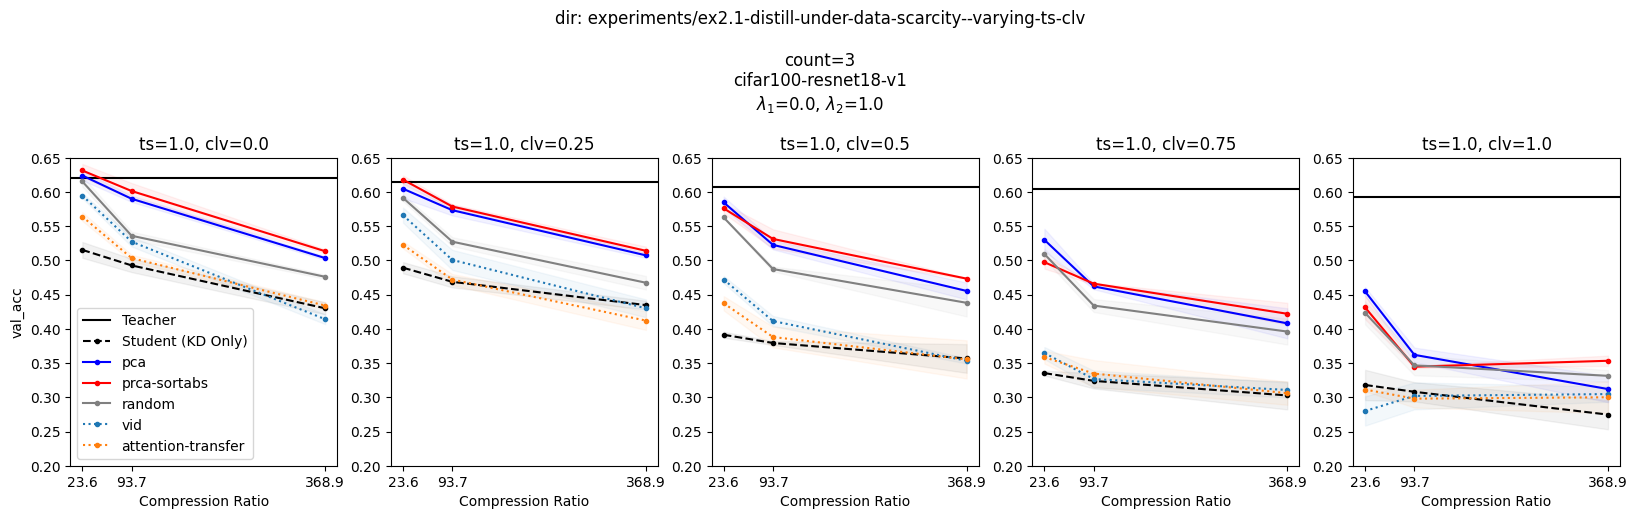

In [57]:
def ls(policy):
    if policy in ["fitnet", "attention-transfer", "vid"] :
        return ":"
    elif policy == "nothing":
        return "--"
    elif policy == "fitnetinvidbnrelu":
        return "-."
    else:
        return "-"
    
def marker(policy, learning_bases_from_clean_data):
    if learning_bases_from_clean_data:
        return "x"
    else:
        return "."

def alias(policy, learning_bases_from_clean_data):
    
    if "basis" in policy:
    
        slug = policy \
            .replace("basis-identity:", "") \
            .replace("--uncentered", "")
        
        if learning_bases_from_clean_data:
            return f"{slug} (from clean ds)"
        else:
            return slug
    
    elif policy == "nothing":
        return "Student (KD Only)"
    
    else:
        return policy

    
def color(policy):
    if "pca" in policy:
        return "blue"
    elif "prca" in policy:
        return "red"
    elif policy == "nothing":
        return "black"
    elif "random" in policy:
        return "gray"
    elif policy == "fitnetinvidinner" or policy == "fitnetinvidbnrelu":
        return plt.gca().lines[-1].get_color()
    else:
        return None
    
def viz_distillation(
    teacher,
    arr_students, 
    policies, 
    training_size,
    arr_contamination_levels,
    show_legend=True,
):
        
    lambda_kd = 1.0
    lambda_task = 0.0
    learning_bases_from_clean_data = False


    col = "val_acc"
    
    ncols = len(arr_contamination_levels)
    nrows = 1
    
    plt.figure(figsize=(4*ncols, 4*nrows))
    
    dirslug = "/".join(f"{EXPERIMENT_GROUP}".split("/")[-2:])
    for cix, contamination_level in enumerate(arr_contamination_levels):
        print(f"working on ts={training_size}, ctv={contamination_level}")
        plt.subplot(nrows, ncols, cix+1)
        plt.title(f"ts={training_size}, clv={contamination_level}")
        
        
        df_main = read_data(
            teacher=teacher,
            policies=policies,
            learning_bases_from_clean_data=learning_bases_from_clean_data,
            lambda_task=lambda_task,
            lambda_kd=lambda_kd,
            training_size=training_size,
            contamination_level=contamination_level,
            arr_students=arr_students,
            verbose=False
        )
        for pix, policy in enumerate(policies):
            df = df_main[df_main["policy"] == policy]
            
            ticks = df["compression_ratio"]

            
            # visualize baseline
            if pix == 0:
                plt.axhline(
                    df["teacher_acc"].values[0],
                    color="k",
                    label="Teacher"
                )
                

                plt.ylim(bottom=0.2, top=0.65)

            # here, we take the first value.
            # the query function already checks that the value is expected
            count = df[col]["count"].values[-1]

            mean = df[col]["mean"]
            stderr = df[col]["std"] / (count ** 0.5)

            plt.plot(
                ticks,
                mean,
                marker=marker(policy, learning_bases_from_clean_data),
                label=alias(policy, learning_bases_from_clean_data),
                ls=ls(policy),
                color=color(policy)
            )

            plt.fill_between(
                ticks,
                mean - stderr,
                mean + stderr,
                alpha=0.05,
                color=plt.gca().lines[-1].get_color()
            )

        plt.xlabel("Compression Ratio")
        plt.xticks(ticks)
        if cix==0:
            plt.ylabel(col)

            plt.legend()

    plt.suptitle(
        "\n".join([
            f"dir: {dirslug}",
            "",
            f"count={count}",
            f"{teacher}",
            f"$\lambda_1$={lambda_task}, $\lambda_2$={lambda_kd}",
        ]),
        y=1.25,
    )

viz_distillation(
    teacher = "cifar100-resnet18-v1",

    training_size=1.0,
    arr_students=[
        "resnet18xscifarcompr1",
        "resnet18xscifarcompr2",
        "resnet18xscifarcompr4",
    ],
    arr_contamination_levels=[0.0, 0.25, 0.5, 0.75, 1.0],
    policies = [ 
        "nothing",
        "basis-identity:pca--uncentered",
        "basis-identity:prca-sortabs--uncentered",
        "basis-identity:random--uncentered",
        "vid",
        "attention-transfer",
    ],
) 

working on ts=1.0, ctv=0.0
working on ts=1.0, ctv=0.25
working on ts=1.0, ctv=0.5
working on ts=1.0, ctv=0.75
working on ts=1.0, ctv=1.0
working on ts=0.5, ctv=0.0
working on ts=0.5, ctv=0.25
working on ts=0.5, ctv=0.5
working on ts=0.5, ctv=0.75
working on ts=0.5, ctv=1.0
working on ts=0.25, ctv=0.0
working on ts=0.25, ctv=0.25
working on ts=0.25, ctv=0.5
working on ts=0.25, ctv=0.75
working on ts=0.25, ctv=1.0
working on ts=0.1, ctv=0.0
working on ts=0.1, ctv=0.25
working on ts=0.1, ctv=0.5
working on ts=0.1, ctv=0.75
working on ts=0.1, ctv=1.0


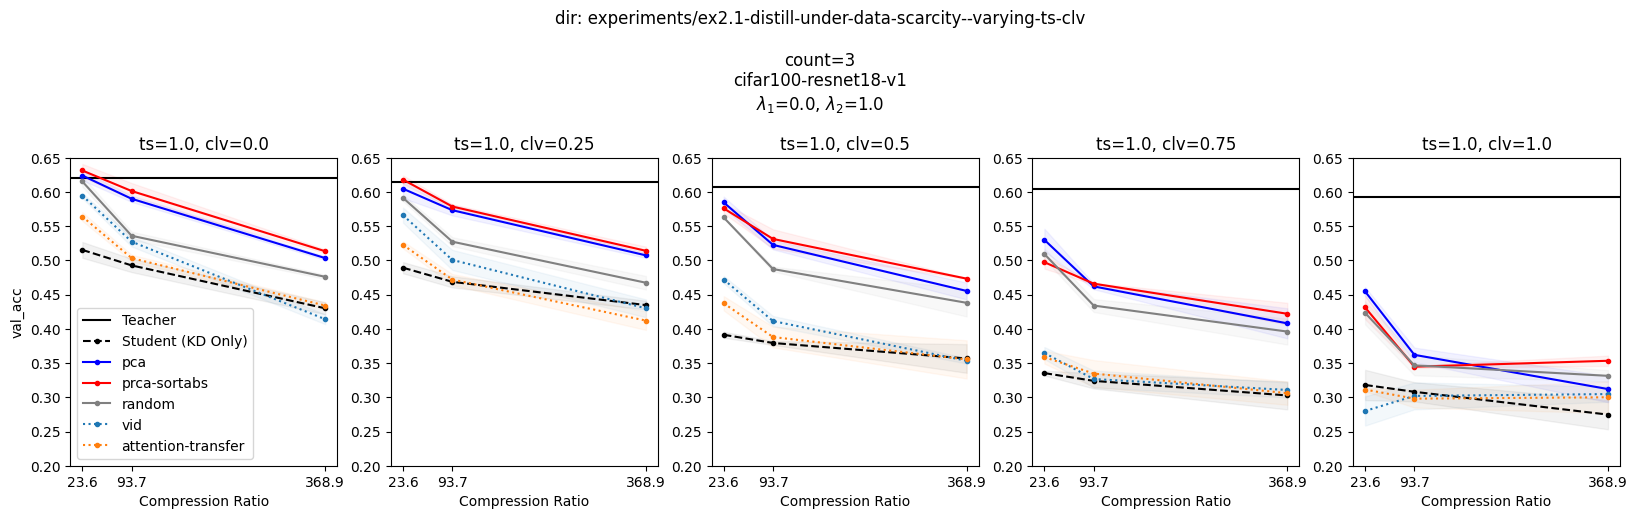

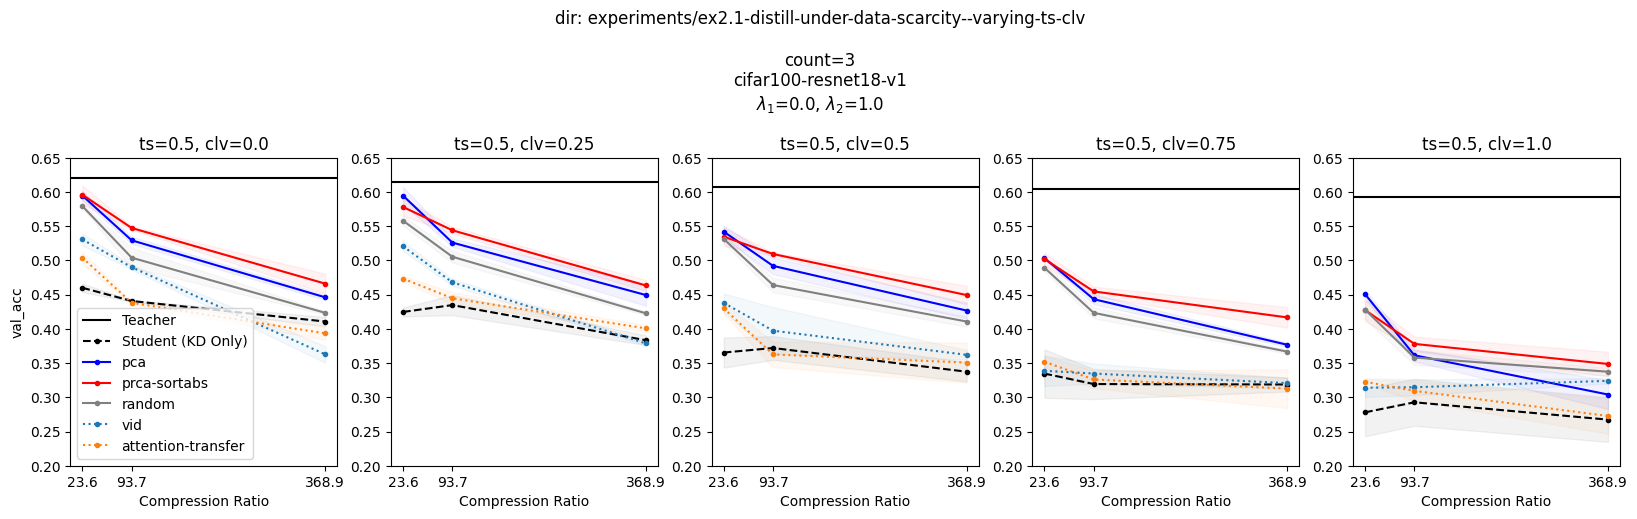

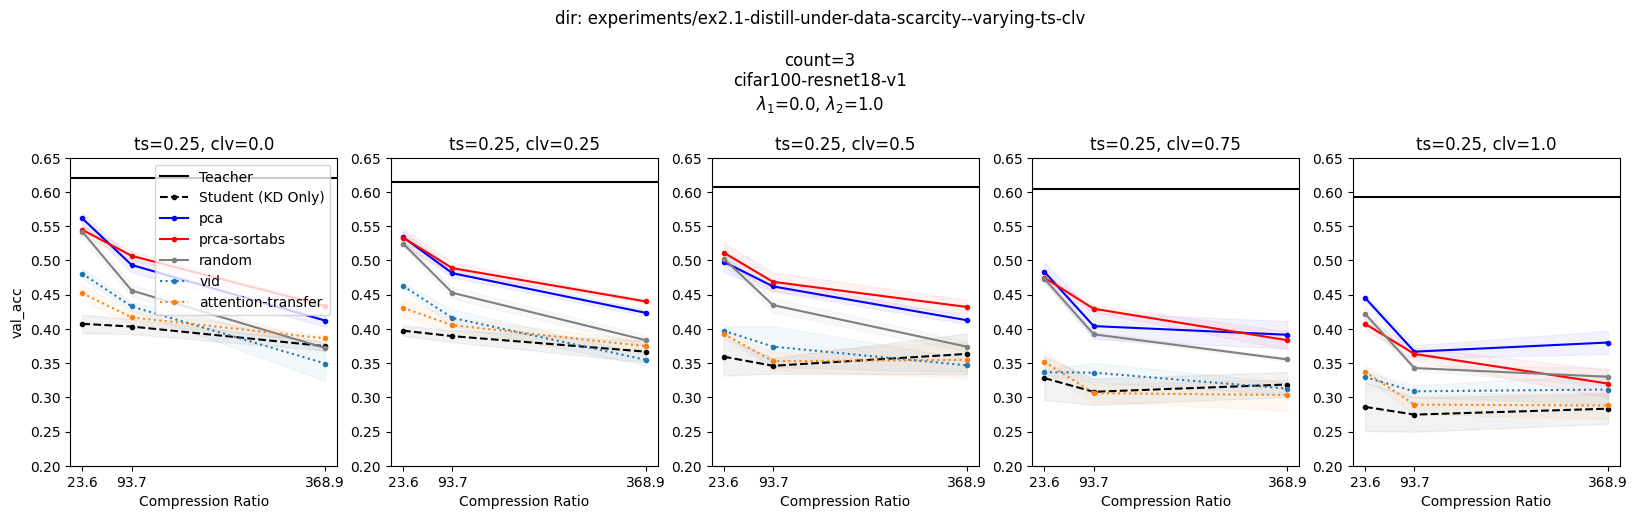

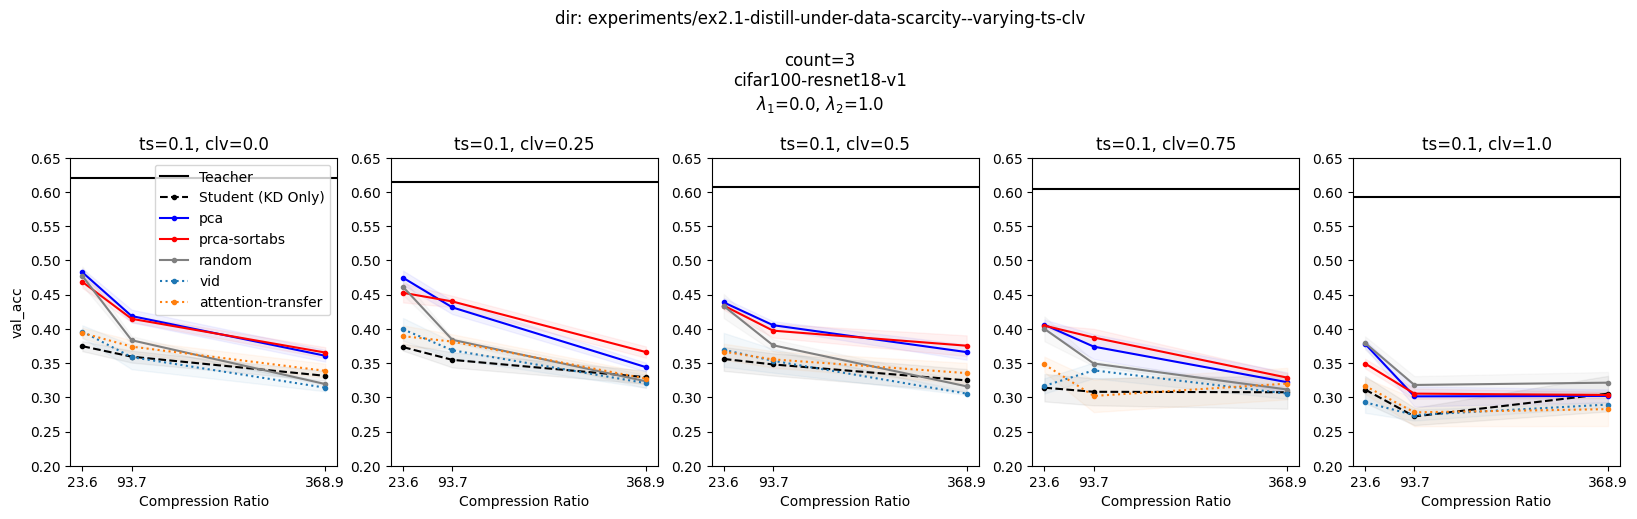

In [58]:
for training_size in [1.0, 0.5, 0.25, 0.1]:

    viz_distillation(
        teacher = "cifar100-resnet18-v1",
        training_size=training_size,
        arr_students=[
            "resnet18xscifarcompr1",
            "resnet18xscifarcompr2",
            "resnet18xscifarcompr4",
        ],
        arr_contamination_levels=[0.0, 0.25, 0.5, 0.75, 1.0],
        policies = [ 
            "nothing",
            "basis-identity:pca--uncentered",
            "basis-identity:prca-sortabs--uncentered",
            "basis-identity:random--uncentered",
            "vid",
            "attention-transfer",
        ],
    ) 

# Summary ..

*Aim*: Investigate the efficacy of PRCA under student size, data quantitiy, and data quality.

*Conclusion*: 
1. `prca` tend to perform well when using with small student models.
2. When data is small, `pca` performs better.
3. When data is small and bad (bottom right plot), `random` is better.